Important Functions

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft
from scipy.signal import hilbert
from scipy.optimize import fsolve
# ================================================================
# SAMPLING FREQUENCY (fixed for all datasets)
# ================================================================
Fs = 20  # Hz (sampling interval is 0.05s)
 
# ================================================================
# SENSOR POSITIONS (x in meters along the flume)
# ================================================================
EMF_POSITIONS = [3.95, 8.06, 14.03, 15.97, 19.98]
WHM_POSITIONS = [3.95, 8.06, 14.03, 15.97, 19.98, 22.01]
 
# ================================================================
# BREAKPOINTS (offshore, onshore) for each wave height case
# ================================================================
BREAKPOINTS = [(21.0, 24.0),   # 3cm
               (18.2, 23.0),   # 6cm
               (16.5, 22.0),   # 9cm
               (13.0, 22.0),   # 12cm
               ( 9.0, 21.0),   # 15cm
               ( 4.0, 21.0)]   # 18cm
 
LABELS = ['Hs=3cm', 'Hs=6cm', 'Hs=9cm', 'Hs=12cm', 'Hs=15cm', 'Hs=18cm']
 
 
# ================================================================
# DATA LOADING FUNCTIONS
# ================================================================
 
def load_emf(filepath):
    raw  = np.genfromtxt(filepath, delimiter=';', skip_header=7)
 
    time = raw[:, 0]
    EMF1 = raw[:, 1]
    EMF2 = raw[:, 2]
    EMF3 = raw[:, 3]
    EMF4 = raw[:, 4]
    EMF5 = raw[:, 5]
 
    # Step 2: remove still water baseline (first 60 seconds)
    still = time < 60
    EMF1 -= np.mean(EMF1[still])
    EMF2 -= np.mean(EMF2[still])
    EMF3 -= np.mean(EMF3[still])
    EMF4 -= np.mean(EMF4[still])
    EMF5 -= np.mean(EMF5[still])
 
    # Step 3: trim first and last 200 seconds
    mask = (time >= 200) & (time <= time[-1] - 200)
    time = time[mask]
    EMF1 = EMF1[mask]
    EMF2 = EMF2[mask]
    EMF3 = EMF3[mask]
    EMF4 = EMF4[mask]
    EMF5 = EMF5[mask]
 
    # Step 4: convert voltage to velocity (calibration factor m/V)
    cal = 0.1023
    EMF1 = EMF1 * cal
    EMF2 = EMF2 * cal
    EMF3 = EMF3 * cal
    EMF4 = EMF4 * cal
    EMF5 = EMF5 * cal
 
    return time, EMF1, EMF2, EMF3, EMF4, EMF5
 
 
def load_whm(filepath):
    raw  = np.genfromtxt(filepath, delimiter=';', skip_header=7)
 
    time = raw[:, 0]
    WHM1 = raw[:, 1]
    WHM2 = raw[:, 2]
    WHM3 = raw[:, 3]
    WHM4 = raw[:, 4]
    WHM5 = raw[:, 5]
    WHM6 = raw[:, 6]
 
    # Step 2: remove still water baseline
    still = time < 60
    WHM1 -= np.mean(WHM1[still])
    WHM2 -= np.mean(WHM2[still])
    WHM3 -= np.mean(WHM3[still])
    WHM4 -= np.mean(WHM4[still])
    WHM5 -= np.mean(WHM5[still])
    WHM6 -= np.mean(WHM6[still])
 
    # Step 3: trim first and last 200 seconds
    mask = (time >= 200) & (time <= time[-1] - 200)
    time = time[mask]
    WHM1 = WHM1[mask]
    WHM2 = WHM2[mask]
    WHM3 = WHM3[mask]
    WHM4 = WHM4[mask]
    WHM5 = WHM5[mask]
    WHM6 = WHM6[mask]
 
    # Step 4: convert voltage to surface elevation (individual calibration factors per sensor)
    WHM1 = WHM1 * 0.0248
    WHM2 = WHM2 * 0.0251
    WHM3 = WHM3 * 0.0251
    WHM4 = WHM4 * 0.0255
    WHM5 = WHM5 * 0.0233
    WHM6 = WHM6 * 0.0214
 
    return time, WHM1, WHM2, WHM3, WHM4, WHM5, WHM6
 
 
def read_grid(filepath, nx=310):
    grp  = np.loadtxt(filepath, skiprows=0)
    ns, no = grp.shape
    nt   = round(ns / nx)
    A    = np.reshape(grp, (nx, nt, no), order='F')
    x    =  A[:, 0, 1]
    zbed = -A[:, 0, 3]
    zbed = zbed - zbed.min()   # shift so flat bottom = 0
    return x, zbed
 
def read_point_output(name_table):
    gauge = np.loadtxt(name_table,skiprows=7)

    t   = gauge[:,0] #time vector (s)
    ux  = gauge[:,2] #depth-averaged velocity in the x-direction (m/s)
    #uy = gauge[:,3] #depth-averaged velocity in the y-direction (0 at all time because we are looking at a 1D case)
    Eta = gauge[:,1] #surface elevation (m)
    return t, Eta, ux #, uy
 
# ================================================================
# SIGNAL PROCESSING FUNCTIONS
# ================================================================
 
def frequency_filter(data, Fs, f_low, f_high):  
    N = len(data)

    fft_data = np.fft.fft(data)  # fourier transform of the signal

    freq_vector = np.fft.fftfreq(N, d=1/Fs) # corresponding (2-sided) frequency axis (includes positive and negative values)
    
    idx = np.where((abs(freq_vector) > f_high) | (abs(freq_vector) <= f_low)) # we select the indices to filter out
    
    fft_data[idx]=0.  # we set the the fourier coefficients corresponding to abs(f)>f_high and abs(f)<f_low to zero

    data_filtered = np.fft.ifft(fft_data).real  # we come back to the time domain with an inverse Fourier transform
    
    return data_filtered
 
 
def compute_spectrum(data, nBlocks=15):
    nfft     = int(len(data) / nBlocks)
    nfft     = nfft - (nfft % 2)           # make sure nfft is even
    df       = Fs / nfft                    # frequency resolution
    f        = np.arange(0, Fs/2 + df, df) # frequency axis from 0 to Nyquist
    blocks   = np.reshape(data[:nBlocks * nfft], (nBlocks, nfft))
    fft_data = 2 * fft(blocks, n=nfft, axis=1)[:, :len(f)] / nfft
    E        = np.mean(np.abs(fft_data)**2 / 2, axis=0) / df
    return f, E
 
 
# ================================================================
# SPECTRAL PARAMETER FUNCTIONS
# ================================================================
 
def compute_hm0(time_series, nBlocks=15):
    data     = time_series - np.mean(time_series)
    f, E     = compute_spectrum(data, nBlocks)
    f        = f[1:]   # skip f=0
    E        = E[1:]
    m0       = np.trapz(E, f)
    return 4 * np.sqrt(m0)
 
 
def compute_tp_tm01(time_series, nBlocks=15):
    data     = time_series - np.mean(time_series)
    f, E     = compute_spectrum(data, nBlocks)
    f        = f[1:]
    E        = E[1:]
    m0       = np.trapz(E, f)
    m1       = np.trapz(E * f, f)
    fp       = f[np.argmax(E)]
    Tp       = 1 / fp
    Tm01     = m0 / m1
    return Tp, Tm01
 
 
def compute_hm0_bands(time_series, nBlocks=15):
    data    = time_series - np.mean(time_series)
    f, E    = compute_spectrum(data, nBlocks)
    ig_mask = (f >= 0.005) & (f <= 0.25)
    ss_mask = (f >= 0.25)  & (f <= 1.0)
    Hm0_ig  = 4 * np.sqrt(np.trapz(E[ig_mask], f[ig_mask]))
    Hm0_ss  = 4 * np.sqrt(np.trapz(E[ss_mask], f[ss_mask]))
    return Hm0_ig, Hm0_ss
 
 
def compute_skewness(time_series):
    eta   = time_series - np.mean(time_series)
    u_ss  = frequency_filter(eta, Fs= 20, f_low=0.25, f_high=9.95)  # sea-swell band
    skewness_ss = np.mean((u_ss)**3) / np.mean((u_ss**2)**1.5)
    return skewness_ss
    
 
def compute_asymmetry(time_series):
    eta      = time_series - np.mean(time_series)
    eta_hat  = np.imag(hilbert(eta))   # Hilbert transform
    sigma    = np.std(eta)
    return np.mean(eta_hat**3) / sigma**3
 
 
def dispersion_relation(k,T, h):
    g = 9.81
    omega = 2 *np.pi / T
    return omega**2 - g * k * np.tanh(k * h)

def compute_ursell(Hs, T, h):
    g     = 9.81
    omega = 2 * np.pi / T
    # solve dispersion relation for k
    k0    = omega / np.sqrt(g * h)  # shallow water initial guess
    k     = fsolve(dispersion_relation, k0, args=(T, h))[0]    
    aw    = 0.5 * Hs
    Ur    = (3/4) * (aw * k) / (k * h)**3
    return Ur, k
 
# ================================================================
# SEDIMENT TRANSPORT FUNCTION
# ================================================================
 
def compute_sediment_transport(time_series):
    u_mean = np.mean(time_series)
    u_dem  = time_series - u_mean         # remove mean
 
    u_ss   = frequency_filter(u_dem, Fs= 20, f_low=0.25,  f_high=4)   # sea-swell band
    u_ig   = frequency_filter(u_dem, Fs= 20, f_low=0.005, f_high=0.25)  # IG band
 
    term_mean    = u_mean**3
    term_skew    = np.mean(u_ss**3)
    term_stir    = np.mean(3 * u_ss**2 * u_mean)
    term_ig      = np.mean(3 * u_ss**2 * u_ig)
    term_total   = term_mean + term_skew + term_stir + term_ig
    term_raw = np.mean(time_series**3)
 
    return term_mean, term_skew, term_stir, term_ig, term_total, term_raw

Load Datasets:

In [73]:
# EMF data (velocity)
time_emf1, EMF1_03, EMF2_03, EMF3_03, EMF4_03, EMF5_03 = load_emf('Set1/EMF_test1.ASC')
time_emf2, EMF1_06, EMF2_06, EMF3_06, EMF4_06, EMF5_06 = load_emf('Set2/EMF_test2.ASC')
time_emf3, EMF1_09, EMF2_09, EMF3_09, EMF4_09, EMF5_09 = load_emf('Set3/EMF_test3.ASC')
time_emf4, EMF1_12, EMF2_12, EMF3_12, EMF4_12, EMF5_12 = load_emf('Set4/EMF_test4.ASC')
time_emf5, EMF1_15, EMF2_15, EMF3_15, EMF4_15, EMF5_15 = load_emf('Set5/EMF_test5.ASC')
time_emf6, EMF1_18, EMF2_18, EMF3_18, EMF4_18, EMF5_18 = load_emf('Set6/EMF_test6.ASC')
 
# WHM data (surface elevation)
time_whm1, WHM1_03, WHM2_03, WHM3_03, WHM4_03, WHM5_03, WHM6_03 = load_whm('Set1/WHM_test1.ASC')
time_whm2, WHM1_06, WHM2_06, WHM3_06, WHM4_06, WHM5_06, WHM6_06 = load_whm('Set2/WHM_test2.ASC')
time_whm3, WHM1_09, WHM2_09, WHM3_09, WHM4_09, WHM5_09, WHM6_09 = load_whm('Set3/WHM_test3.ASC')
time_whm4, WHM1_12, WHM2_12, WHM3_12, WHM4_12, WHM5_12, WHM6_12 = load_whm('Set4/WHM_test4.ASC')
time_whm5, WHM1_15, WHM2_15, WHM3_15, WHM4_15, WHM5_15, WHM6_15 = load_whm('Set5/WHM_test5.ASC')
time_whm6, WHM1_18, WHM2_18, WHM3_18, WHM4_18, WHM5_18, WHM6_18 = load_whm('Set6/WHM_test6.ASC')

#load swash
time1_swash, Eta1_1, ux1_1 = read_point_output('Set1Swash/gauge1.tbl')
time1_swash, Eta1_2, ux1_2 = read_point_output('Set1Swash/gauge2.tbl')
time1_swash, Eta1_3, ux1_3 = read_point_output('Set1Swash/gauge3.tbl')
time1_swash, Eta1_4, ux1_4 = read_point_output('Set1Swash/gauge4.tbl')
time1_swash, Eta1_5, ux1_5 = read_point_output('Set1Swash/gauge5.tbl')
time1_swash, Eta1_6, ux1_6 = read_point_output('Set1Swash/gauge6.tbl')

time2_swash, Eta2_1, ux2_1 = read_point_output('Set2Swash/gauge1.tbl')
time2_swash, Eta2_2, ux2_2 = read_point_output('Set2Swash/gauge2.tbl')
time2_swash, Eta2_3, ux2_3 = read_point_output('Set2Swash/gauge3.tbl')
time2_swash, Eta2_4, ux2_4 = read_point_output('Set2Swash/gauge4.tbl')
time2_swash, Eta2_5, ux2_5 = read_point_output('Set2Swash/gauge5.tbl')
time2_swash, Eta2_6, ux2_6 = read_point_output('Set2Swash/gauge6.tbl')

time3_swash, Eta3_1, ux3_1 = read_point_output('Set3Swash/gauge1.tbl')
time3_swash, Eta3_2, ux3_2 = read_point_output('Set3Swash/gauge2.tbl')
time3_swash, Eta3_3, ux3_3 = read_point_output('Set3Swash/gauge3.tbl')
time3_swash, Eta3_4, ux3_4 = read_point_output('Set3Swash/gauge4.tbl')
time3_swash, Eta3_5, ux3_5 = read_point_output('Set3Swash/gauge5.tbl')
time3_swash, Eta3_6, ux3_6 = read_point_output('Set3Swash/gauge6.tbl')

time4_swash, Eta4_1, ux4_1 = read_point_output('Set4Swash/gauge1.tbl')
time4_swash, Eta4_2, ux4_2 = read_point_output('Set4Swash/gauge2.tbl')
time4_swash, Eta4_3, ux4_3 = read_point_output('Set4Swash/gauge3.tbl')
time4_swash, Eta4_4, ux4_4 = read_point_output('Set4Swash/gauge4.tbl')
time4_swash, Eta4_5, ux4_5 = read_point_output('Set4Swash/gauge5.tbl')
time4_swash, Eta4_6, ux4_6 = read_point_output('Set4Swash/gauge6.tbl')

time5_swash, Eta5_1, ux5_1 = read_point_output('Set5Swash/gauge1.tbl')
time5_swash, Eta5_2, ux5_2 = read_point_output('Set5Swash/gauge2.tbl')
time5_swash, Eta5_3, ux5_3 = read_point_output('Set5Swash/gauge3.tbl')
time5_swash, Eta5_4, ux5_4 = read_point_output('Set5Swash/gauge4.tbl')
time5_swash, Eta5_5, ux5_5 = read_point_output('Set5Swash/gauge5.tbl')
time5_swash, Eta5_6, ux5_6 = read_point_output('Set5Swash/gauge6.tbl')

time6_swash, Eta6_1, ux6_1 = read_point_output('Set6Swash/gauge1.tbl')
time6_swash, Eta6_2, ux6_2 = read_point_output('Set6Swash/gauge2.tbl')
time6_swash, Eta6_3, ux6_3 = read_point_output('Set6Swash/gauge3.tbl')
time6_swash, Eta6_4, ux6_4 = read_point_output('Set6Swash/gauge4.tbl')
time6_swash, Eta6_5, ux6_5 = read_point_output('Set6Swash/gauge5.tbl')
time6_swash, Eta6_6, ux6_6 = read_point_output('Set6Swash/gauge6.tbl')
# Grid
x, zbed = read_grid('grid_output.tbl')
 

Compute all parameters for spectral analysis:

In [74]:
time_whm_list = [time_whm1, time_whm2, time_whm3, time_whm4, time_whm5, time_whm6]
 
WHM1_list = [WHM1_03, WHM1_06, WHM1_09, WHM1_12, WHM1_15, WHM1_18]
WHM2_list = [WHM2_03, WHM2_06, WHM2_09, WHM2_12, WHM2_15, WHM2_18]
WHM3_list = [WHM3_03, WHM3_06, WHM3_09, WHM3_12, WHM3_15, WHM3_18]
WHM4_list = [WHM4_03, WHM4_06, WHM4_09, WHM4_12, WHM4_15, WHM4_18]
WHM5_list = [WHM5_03, WHM5_06, WHM5_09, WHM5_12, WHM5_15, WHM5_18]
WHM6_list = [WHM6_03, WHM6_06, WHM6_09, WHM6_12, WHM6_15, WHM6_18]

Hm0_all    = []
Tp_all     = []
Tm01_all   = []
Hm0_ig_all = []
Hm0_ss_all = []

for case_idx in range(6):
    WHMs = [WHM1_list[case_idx], WHM2_list[case_idx], WHM3_list[case_idx],
            WHM4_list[case_idx], WHM5_list[case_idx], WHM6_list[case_idx]]
 
    hm0_case    = []
    tp_case     = []
    tm01_case   = []
    hm0_ig_case = []
    hm0_ss_case = []

    for WHM in WHMs:
        hm0_case.append(compute_hm0(WHM))
        Tp, Tm01 = compute_tp_tm01(WHM)
        tp_case.append(Tp)
        tm01_case.append(Tm01)
        Hm0_ig, Hm0_ss = compute_hm0_bands(WHM)
        hm0_ig_case.append(Hm0_ig)
        hm0_ss_case.append(Hm0_ss)
    
    Hm0_all.append(hm0_case)
    Tp_all.append(tp_case)
    Tm01_all.append(tm01_case)
    Hm0_ig_all.append(hm0_ig_case)
    Hm0_ss_all.append(hm0_ss_case)

Compute Sediment Transport

In [75]:
time_emf_list = [time_emf1, time_emf2, time_emf3, time_emf4, time_emf5]
 
EMF1_list = [EMF1_03, EMF1_06, EMF1_09, EMF1_12, EMF1_15, EMF1_18]
EMF2_list = [EMF2_03, EMF2_06, EMF2_09, EMF2_12, EMF2_15, EMF2_18]
EMF3_list = [EMF3_03, EMF3_06, EMF3_09, EMF3_12, EMF3_15, EMF3_18]
EMF4_list = [EMF4_03, EMF4_06, EMF4_09, EMF4_12, EMF4_15, EMF4_18]
EMF5_list = [EMF5_03, EMF5_06, EMF5_09, EMF5_12, EMF5_15, EMF5_18]

Mean_all  = []
Skew_all  = []
Stir_all  = []
IG_all    = []
Total_all = []
Raw_all   = []

for case_idx in range(6):
    EMFs = [EMF1_list[case_idx], EMF2_list[case_idx], EMF3_list[case_idx],
            EMF4_list[case_idx], EMF5_list[case_idx]]
 
    mean_case  = []
    skew_case  = []
    stir_case  = []
    ig_case    = []
    total_case = []
    raw_case   = []
 
    for EMF in EMFs:
        m, sk, st, ig, tot, raw = compute_sediment_transport(EMF)
        mean_case.append(m)
        skew_case.append(sk)
        stir_case.append(st)
        ig_case.append(ig)
        total_case.append(tot)
        raw_case.append(raw)
        
 
    Mean_all.append(mean_case)
    Skew_all.append(skew_case)
    Stir_all.append(stir_case)
    IG_all.append(ig_case)
    Total_all.append(total_case)
    Raw_all.append(raw_case)
 

Calculate Swash Sediment Moments:

In [88]:
# SWASH time lists (if they differ between runs, otherwise you can just use time1_swash)
time_swash_list = [time1_swash, time2_swash, time3_swash, time4_swash, time5_swash, time6_swash]

# SWASH Elevation (Eta) lists grouped by sensor
Eta1_list = [Eta1_1, Eta2_1, Eta3_1, Eta4_1, Eta5_1, Eta6_1]
Eta2_list = [Eta1_2, Eta2_2, Eta3_2, Eta4_2, Eta5_2, Eta6_2]
Eta3_list = [Eta1_3, Eta2_3, Eta3_3, Eta4_3, Eta5_3, Eta6_3]
Eta4_list = [Eta1_4, Eta2_4, Eta3_4, Eta4_4, Eta5_4, Eta6_4]
Eta5_list = [Eta1_5, Eta2_5, Eta3_5, Eta4_5, Eta5_5, Eta6_5]
Eta6_list = [Eta1_6, Eta2_6, Eta3_6, Eta4_6, Eta5_6, Eta6_6]

# SWASH Velocity (ux) lists grouped by sensor
ux1_list = [ux1_1, ux2_1, ux3_1, ux4_1, ux5_1, ux6_1]
ux2_list = [ux1_2, ux2_2, ux3_2, ux4_2, ux5_2, ux6_2]
ux3_list = [ux1_3, ux2_3, ux3_3, ux4_3, ux5_3, ux6_3]
ux4_list = [ux1_4, ux2_4, ux3_4, ux4_4, ux5_4, ux6_4]
ux5_list = [ux1_5, ux2_5, ux3_5, ux4_5, ux5_5, ux6_5]

# Initialize SWASH sediment transport lists
Mean_swash_all  = []
Skew_swash_all  = []
Stir_swash_all  = []
IG_swash_all    = []
Total_swash_all = []
Raw_swash_all   = []

for case_idx in range(6):
    # Group the 6 SWASH gauges for this specific experiment case
    # Assuming you defined ux1_list, ux2_list... previously
    UXs = [ux1_list[case_idx], ux2_list[case_idx], ux3_list[case_idx],
           ux4_list[case_idx], ux5_list[case_idx]]
 
    mean_case_sw  = []
    skew_case_sw  = []
    stir_case_sw  = []
    ig_case_sw    = []
    total_case_sw = []
    raw_case_sw   = []
 
    for ux in UXs:
        # Compute transport using the numerical velocity (ux) from SWASH
        m, sk, st, ig, tot, raw = compute_sediment_transport(ux)
        mean_case_sw.append(m)
        skew_case_sw.append(sk)
        stir_case_sw.append(st)
        ig_case_sw.append(ig)
        total_case_sw.append(tot)
        raw_case_sw.append(raw)
 
    Mean_swash_all.append(mean_case_sw)
    Skew_swash_all.append(skew_case_sw)
    Stir_swash_all.append(stir_case_sw)
    IG_swash_all.append(ig_case_sw)
    Total_swash_all.append(total_case_sw)
    Raw_swash_all.append(raw_case_sw)

Visualize Flume:

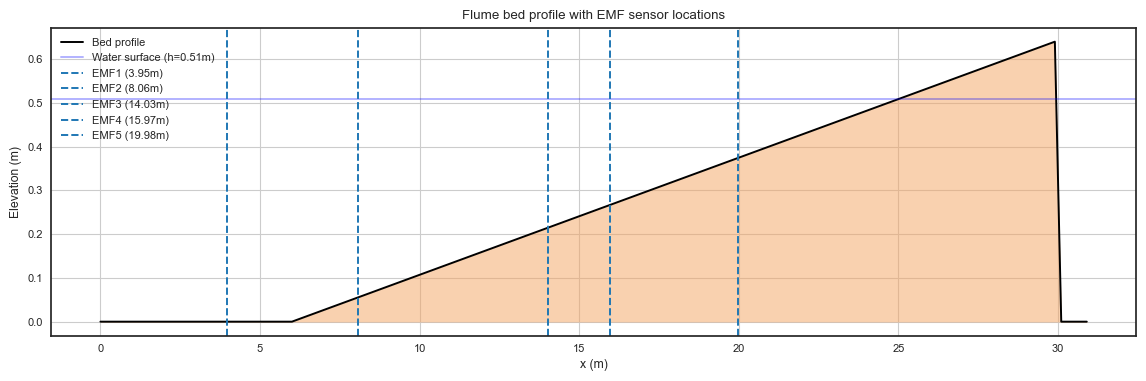

In [77]:
water_levels = {1: 0.510, 2: 0.509, 3: 0.508, 4: 0.507, 5: 0.506, 6: 0.505}
 
plt.figure(figsize=(14, 4))
plt.plot(x, zbed, color='black', label='Bed profile')
plt.fill_between(x, zbed, 0, color='sandybrown', alpha=0.5)
plt.axhline(y=0.51, color='blue', alpha=0.3, label='Water surface (h=0.51m)')
for i, pos in enumerate(EMF_POSITIONS):
    plt.axvline(x=pos, linestyle='--', label=f'EMF{i+1} ({pos}m)')
plt.xlabel('x (m)')
plt.ylabel('Elevation (m)')
plt.title('Flume bed profile with EMF sensor locations')
plt.legend(loc='upper left')
plt.grid()
plt.show()
 

Visualize Cross-shore Evolution of Spectrum:

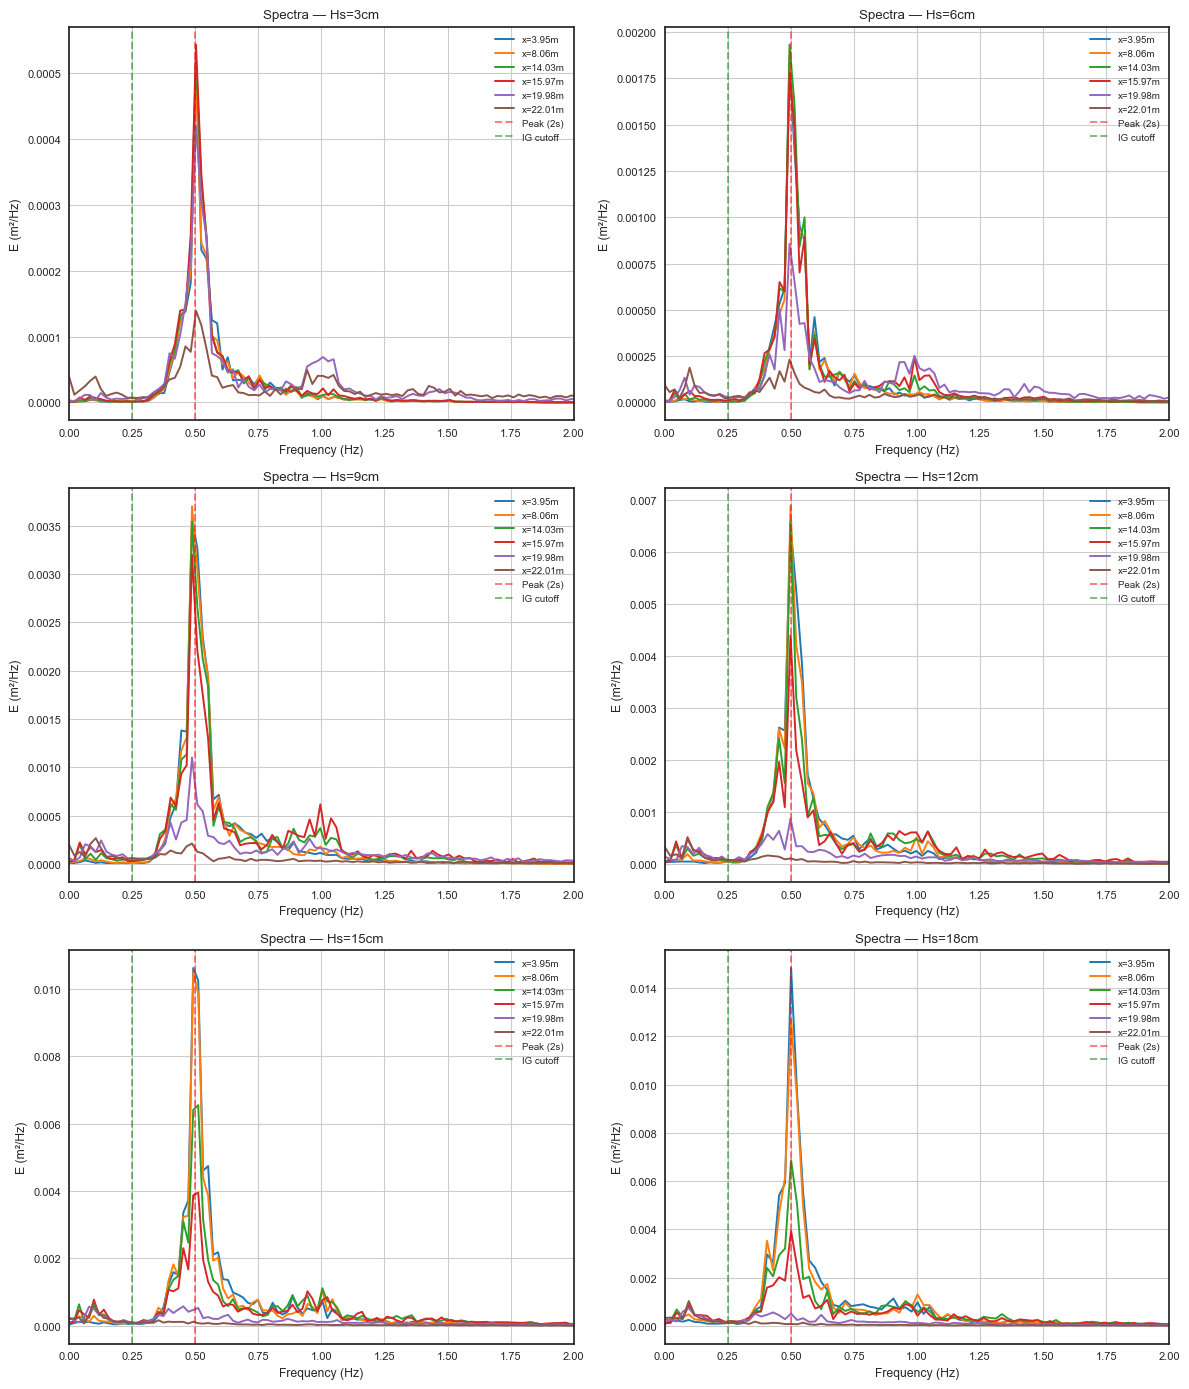

In [78]:
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flatten()
 
WHM_all = [
    [WHM1_03, WHM2_03, WHM3_03, WHM4_03, WHM5_03, WHM6_03],
    [WHM1_06, WHM2_06, WHM3_06, WHM4_06, WHM5_06, WHM6_06],
    [WHM1_09, WHM2_09, WHM3_09, WHM4_09, WHM5_09, WHM6_09],
    [WHM1_12, WHM2_12, WHM3_12, WHM4_12, WHM5_12, WHM6_12],
    [WHM1_15, WHM2_15, WHM3_15, WHM4_15, WHM5_15, WHM6_15],
    [WHM1_18, WHM2_18, WHM3_18, WHM4_18, WHM5_18, WHM6_18],
]
 
for i in range(6):
    for j, (WHM, pos) in enumerate(zip(WHM_all[i], WHM_POSITIONS)):
        f, E = compute_spectrum(WHM - np.mean(WHM))
        axes[i].plot(f, E, label=f'x={pos}m')
    axes[i].axvline(x=0.5,  linestyle='--', color='red',   alpha=0.5, label='Peak (2s)')
    axes[i].axvline(x=0.25, linestyle='--', color='green', alpha=0.5, label='IG cutoff')
    axes[i].set_xlim(0, 2)
    axes[i].set_xlabel('Frequency (Hz)')
    axes[i].set_ylabel('E (m²/Hz)')
    axes[i].set_title(f'Spectra — {LABELS[i]}')
    axes[i].legend(fontsize=7)
    axes[i].grid()
 
plt.tight_layout()
plt.show()

Visualize Cross-Shore Evolution of Hm0:

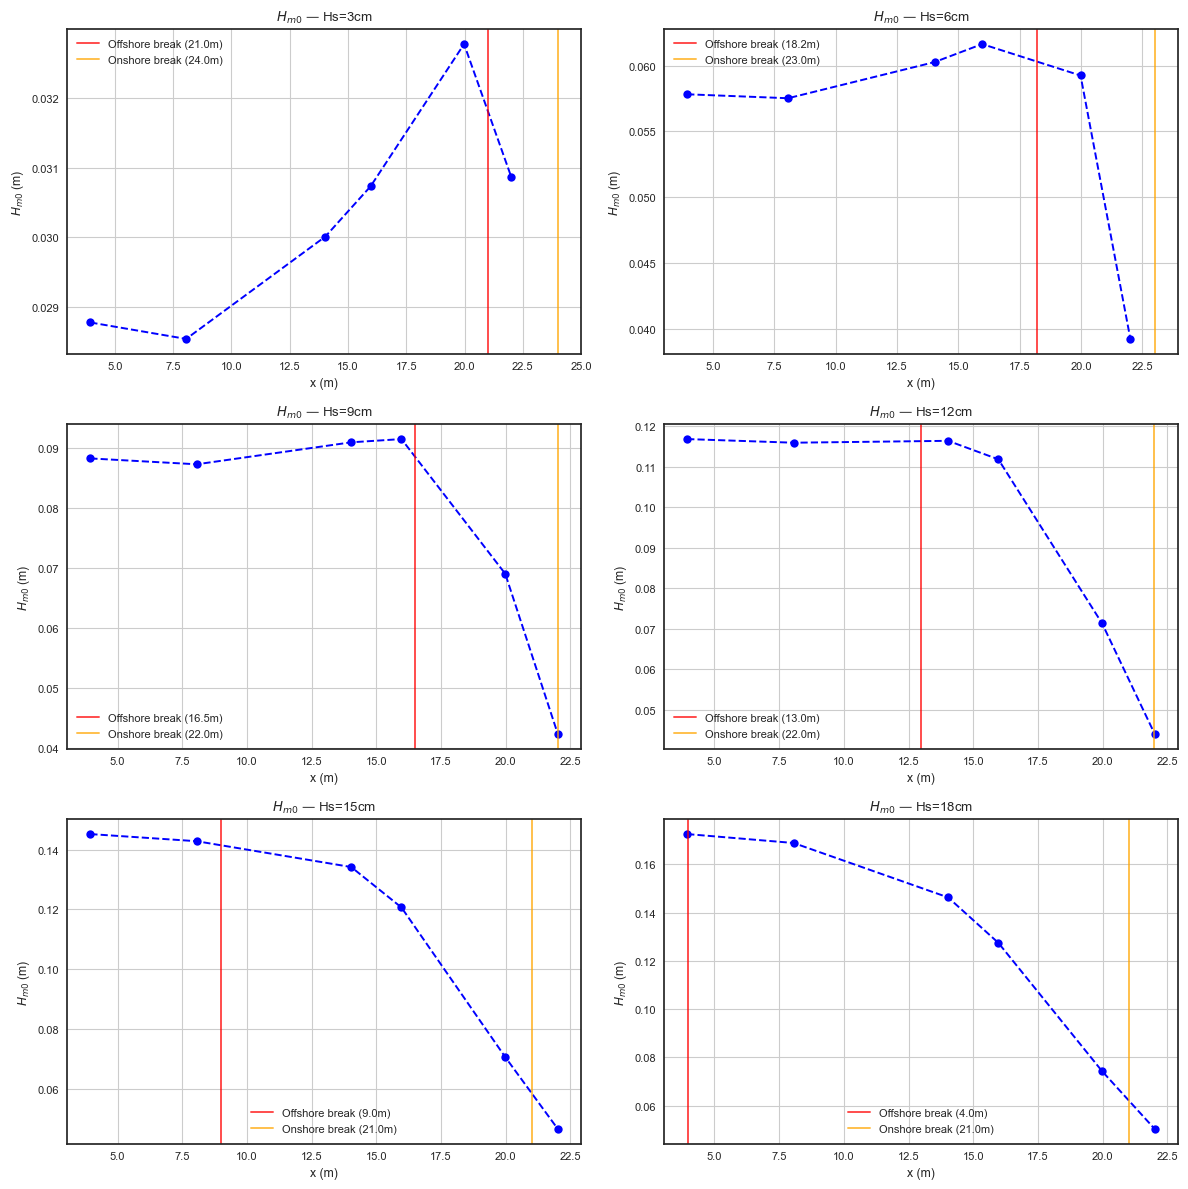

In [79]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()
 
for i in range(6):
    axes[i].plot(WHM_POSITIONS, Hm0_all[i], linestyle='--', marker='o', markersize=6, color='blue')
    axes[i].axvline(x=BREAKPOINTS[i][0], color='red',    alpha=0.7, label=f'Offshore break ({BREAKPOINTS[i][0]}m)')
    axes[i].axvline(x=BREAKPOINTS[i][1], color='orange', alpha=0.7, label=f'Onshore break ({BREAKPOINTS[i][1]}m)')
    axes[i].set_xlabel('x (m)')
    axes[i].set_ylabel('$H_{m0}$ (m)')
    axes[i].set_title(f'$H_{{m0}}$ — {LABELS[i]}')
    axes[i].legend(fontsize=8)
    axes[i].grid()
 
plt.tight_layout()
plt.show()

Cross-shore Evolution of Tm0 and Tp:

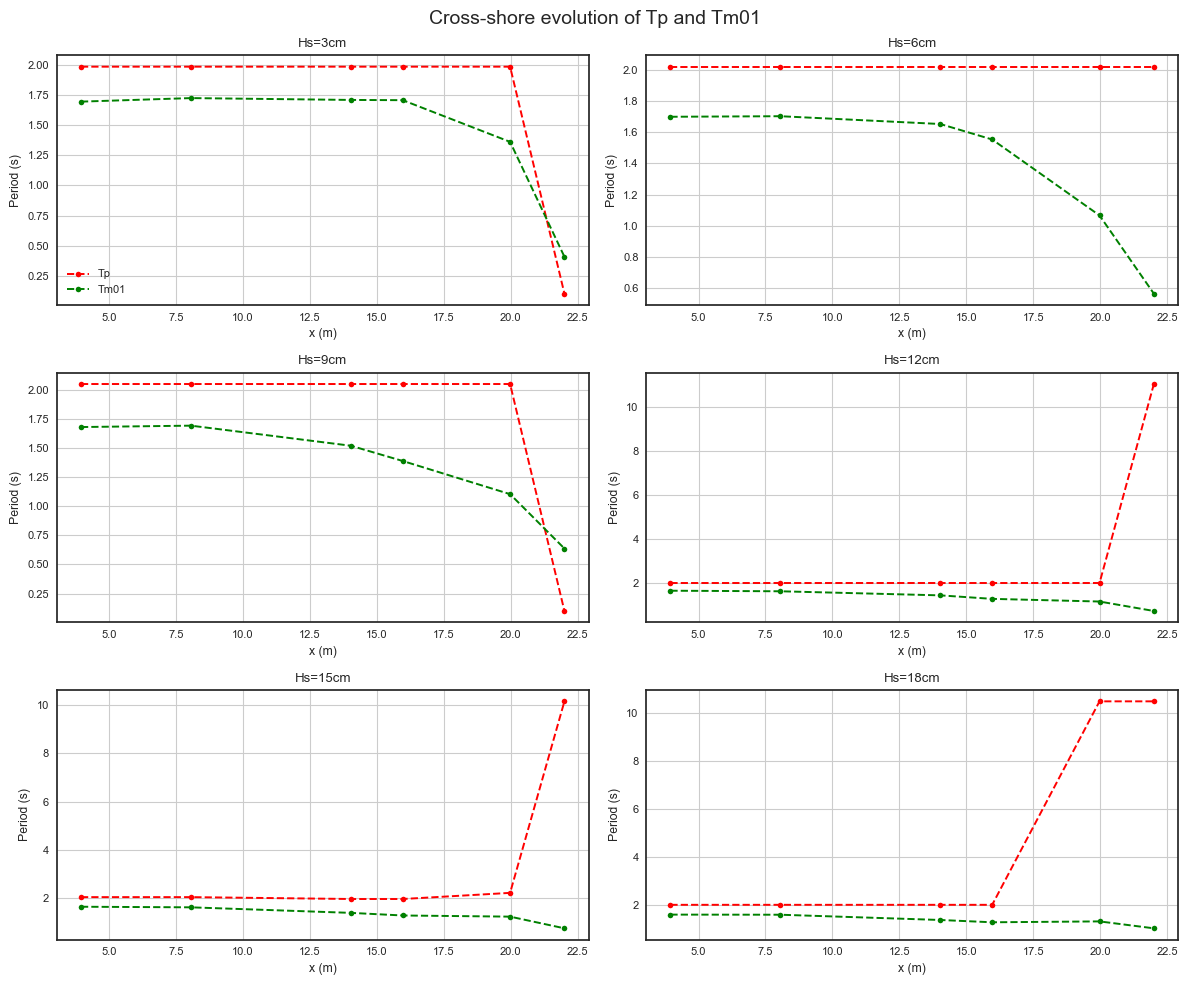

In [80]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()
 
for i in range(6):
    axes[i].plot(WHM_POSITIONS, Tp_all[i],   color='red',   marker='o', linestyle='--', markersize=4, label='Tp')
    axes[i].plot(WHM_POSITIONS, Tm01_all[i], color='green', marker='o', linestyle='--', markersize=4, label='Tm01')
    axes[i].set_xlabel('x (m)')
    axes[i].set_ylabel('Period (s)')
    axes[i].set_title(LABELS[i])
    axes[i].grid()
 
axes[0].legend()
plt.suptitle('Cross-shore evolution of Tp and Tm01', fontsize=14)
plt.tight_layout()
plt.show()

Cross-shore Evolution of Wave-Setup:

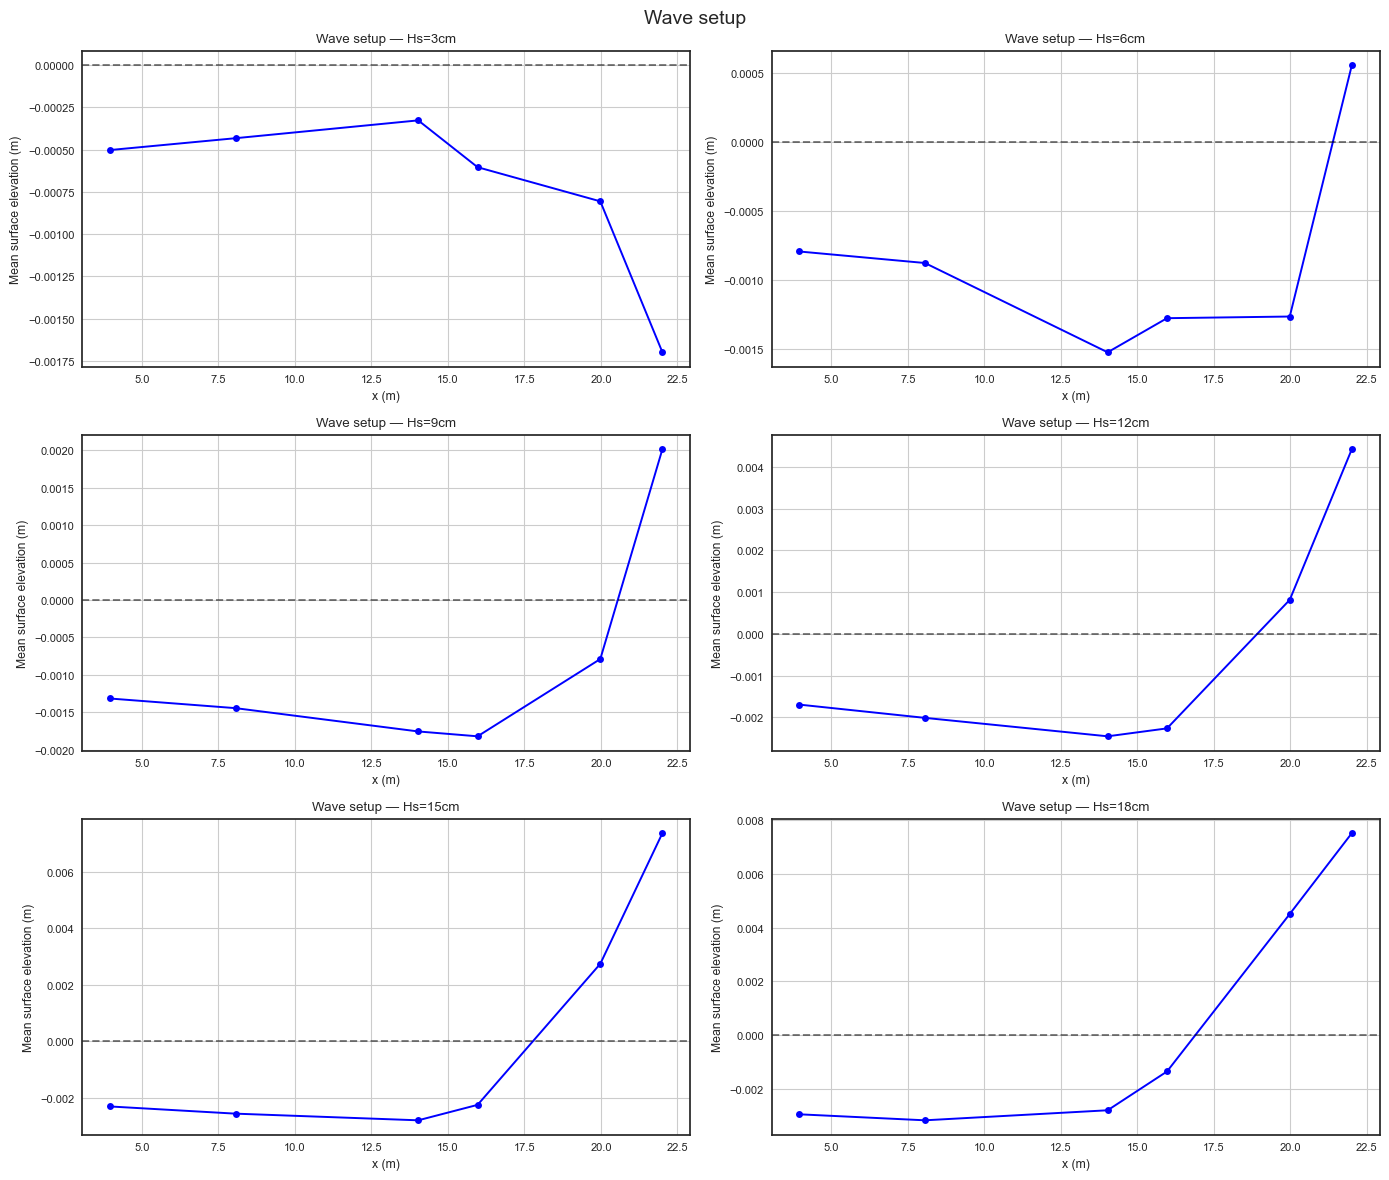

In [81]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()
 
for i in range(6):
    setup = [np.mean(WHM) for WHM in WHM_all[i]]
    axes[i].plot(WHM_POSITIONS, setup, color='blue', marker='o', markersize=5)
    axes[i].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[i].set_xlabel('x (m)')
    axes[i].set_ylabel('Mean surface elevation (m)')
    axes[i].set_title(f'Wave setup — {LABELS[i]}')
    axes[i].grid()
 
plt.suptitle('Wave setup', fontsize=14)
plt.tight_layout()
plt.show()

Cross-shore Evolution of Hm_ig and Hm_ss

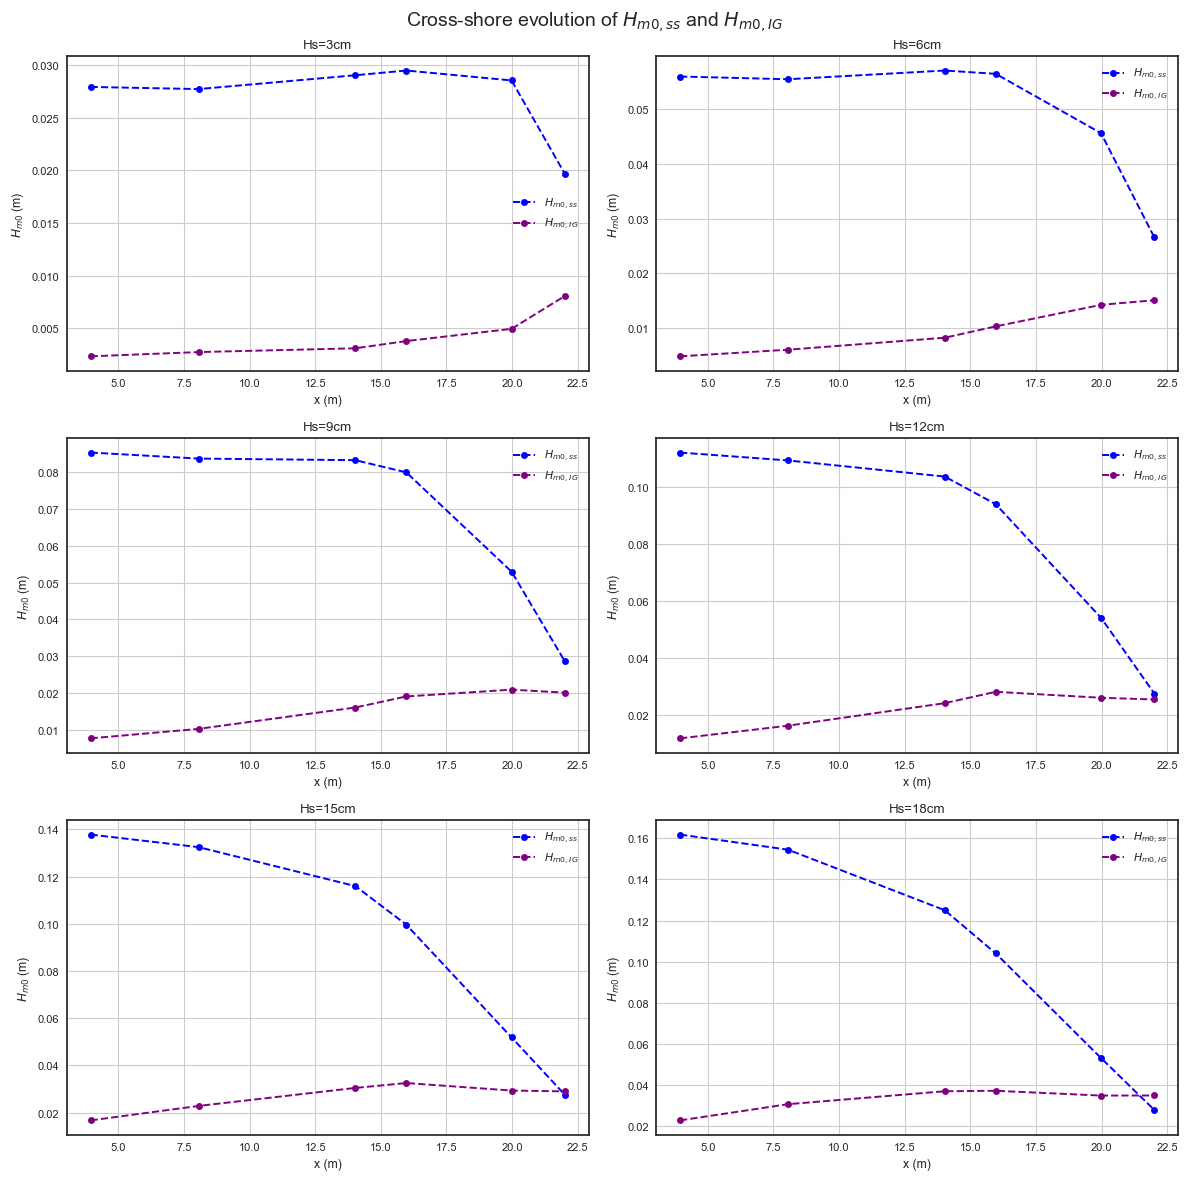

In [82]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()
 
for i in range(6):
    axes[i].plot(WHM_POSITIONS, Hm0_ss_all[i], color='blue',   marker='o', linestyle='--', markersize=5, label='$H_{m0,ss}$')
    axes[i].plot(WHM_POSITIONS, Hm0_ig_all[i], color='purple', marker='o', linestyle='--', markersize=5, label='$H_{m0,IG}$')
    axes[i].set_xlabel('x (m)')
    axes[i].set_ylabel('$H_{m0}$ (m)')
    axes[i].set_title(LABELS[i])
    axes[i].legend()
    axes[i].grid()
 
plt.suptitle('Cross-shore evolution of $H_{m0,ss}$ and $H_{m0,IG}$', fontsize=14)
plt.tight_layout()
plt.show()

Cross shore Evolution of third velocity Moments:

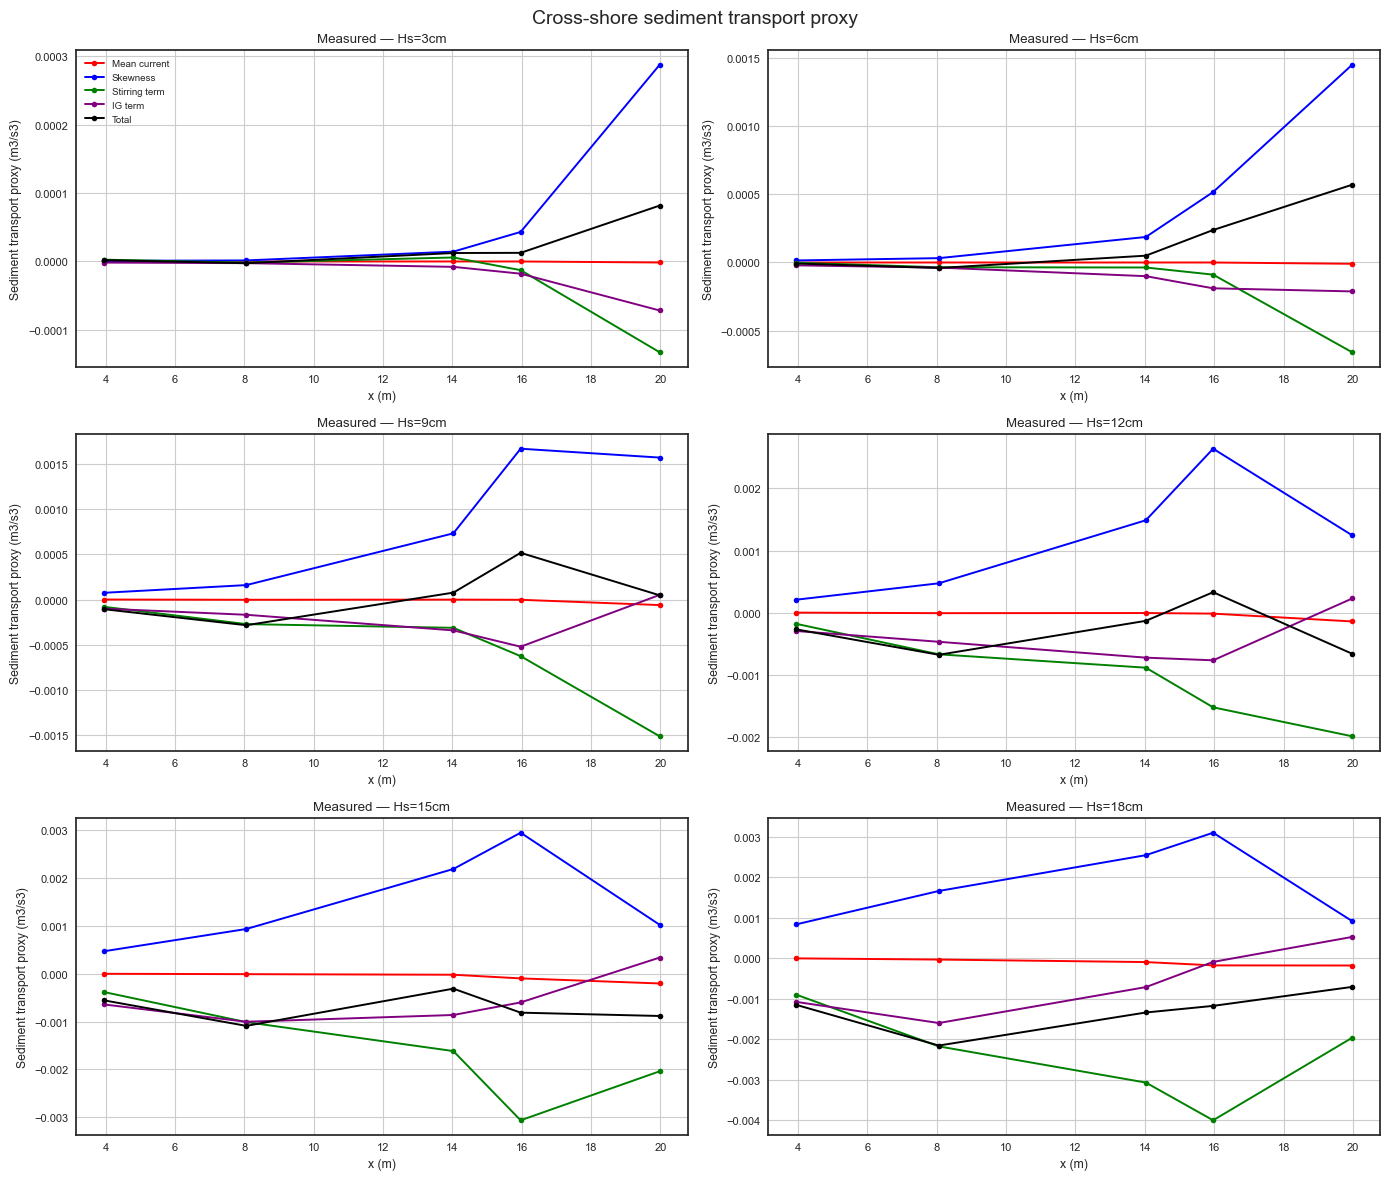

In [83]:
# Create the 3x2 grid
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Flatten the 2D array to 1D for easy iteration
axes_flat = axes.flatten()

for i, case_idx in enumerate([0, 1, 2, 3, 4, 5]):
    ax = axes_flat[i]
    ax.plot(EMF_POSITIONS, Mean_all[case_idx],  color='red',    marker='o', markersize=4, label='Mean current')
    ax.plot(EMF_POSITIONS, Skew_all[case_idx],  color='blue',   marker='o', markersize=4, label='Skewness')
    ax.plot(EMF_POSITIONS, Stir_all[case_idx],  color='green',  marker='o', markersize=4, label='Stirring term')
    ax.plot(EMF_POSITIONS, IG_all[case_idx],    color='purple', marker='o', markersize=4, label='IG term')
    ax.plot(EMF_POSITIONS, Total_all[case_idx], color='black',  marker='o', markersize=4, label='Total')
    
    ax.set_xlabel('x (m)')
    ax.set_ylabel('Sediment transport proxy (m3/s3)')
    ax.set_title(f'Measured — {LABELS[case_idx]}')
    ax.grid()

axes_flat[0].legend(fontsize=7)

plt.suptitle('Cross-shore sediment transport proxy', fontsize=14)
plt.tight_layout()
plt.show()


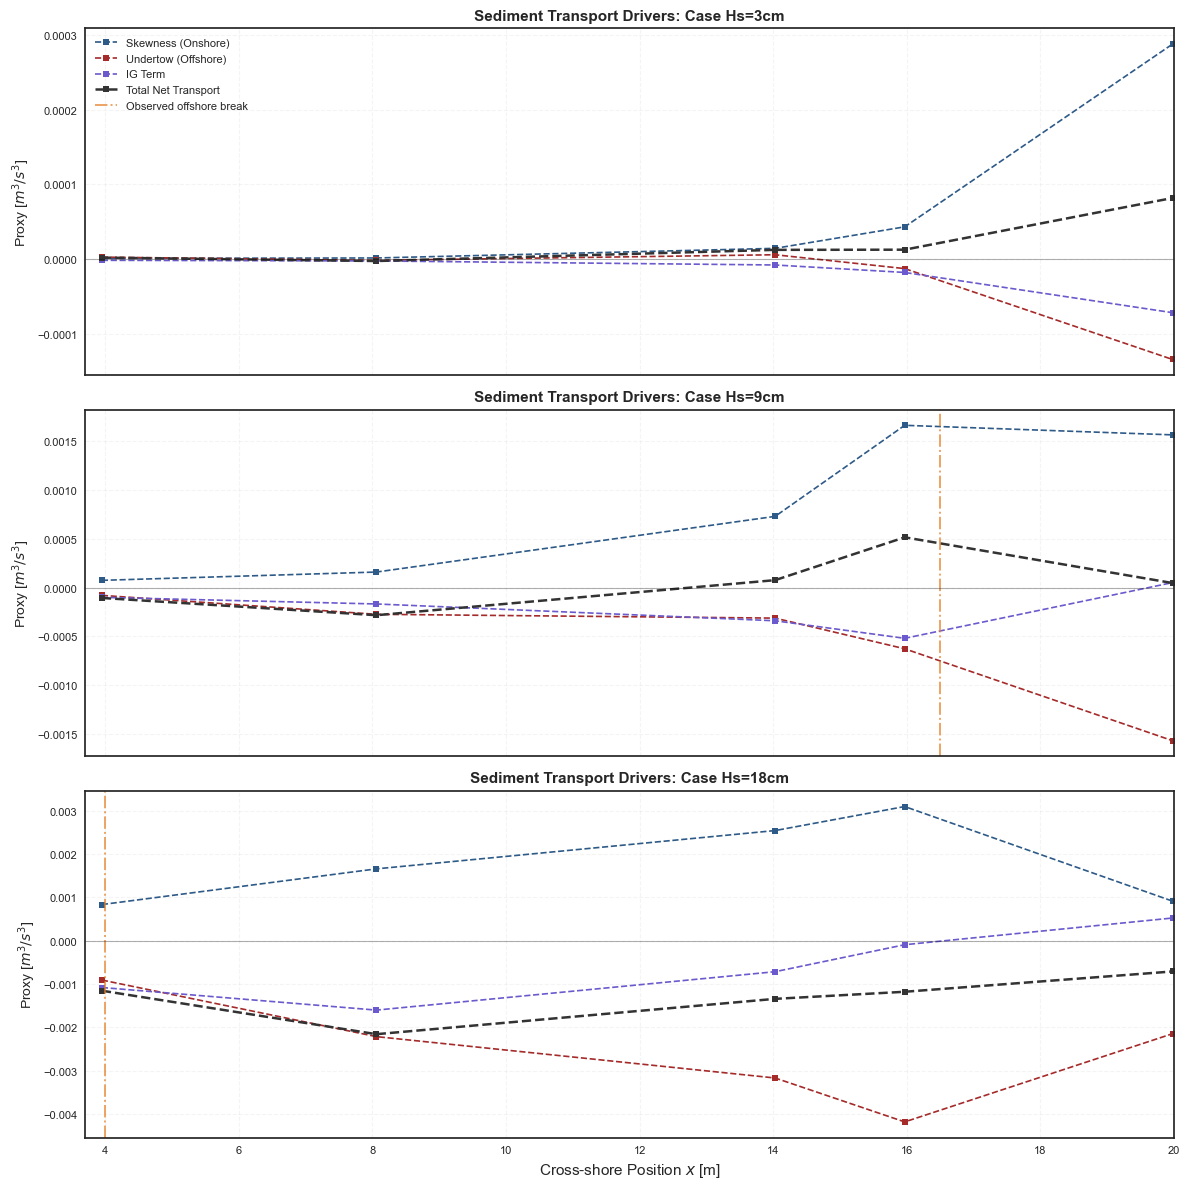

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup indices and positions
target_indices = [0, 2, 5]
pos = np.array(EMF_POSITIONS)

# 2. Professional Color Palette
colors = {
    'skew': '#2E5A88',      # Midnight Blue
    'undertow': '#A52A2A',  # Muted Crimson
    'ig': '#6A5ACD',        # Slate Purple
    'total': '#333333',     # Charcoal
    'break1': '#E67E22',    # Soft Orange
    'break2': '#D35400'     # Burnt Orange
}

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for i, idx in enumerate(target_indices):
    ax = axes[i]
    
    # Calculate Undertow (Mean + Stir)
    undertow = np.array(Mean_all[idx]) + np.array(Stir_all[idx])
    
    # 3. Plotting with uniform small rectangles ('s') and dashed/dotted lines
    # All markers set to size 5
    m_size = 5
    
    ax.plot(pos, Skew_all[idx], color=colors['skew'], marker='s', markersize=m_size, 
            linestyle='--', linewidth=1.2, label='Skewness (Onshore)')
    
    ax.plot(pos, undertow, color=colors['undertow'], marker='s', markersize=m_size, 
            linestyle='--', linewidth=1.2, label='Undertow (Offshore)')
    
    ax.plot(pos, IG_all[idx], color=colors['ig'], marker='s', markersize=m_size, 
            linestyle='--', linewidth=1.2, label='IG Term')
    
    ax.plot(pos, Total_all[idx], color=colors['total'], marker='s', markersize=m_size, 
            linestyle='--', linewidth=1.8, label='Total Net Transport')

    # 4. Break Points
    off_b = BREAKPOINTS[idx][0]
    on_b  = BREAKPOINTS[idx][1]
    
    ax.axvline(x=off_b, color=colors['break1'], linestyle='-.', alpha=0.7, 
               label=f'Observed offshore break')


    # 5. Framing and Labels
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.3)
    ax.set_title(f'Sediment Transport Drivers: Case {LABELS[idx]}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Proxy [$m^3/s^3$]', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.2)
    
    # 6. Only one legend for the whole figure, placed inside the first plot
    if i == 0:
        ax.legend(loc='upper left', fontsize=8, framealpha=0.9, edgecolor='inherit')

# Common X-axis label
axes[-1].set_xlabel('Cross-shore Position $x$ [m]', fontsize=11)

# Ensure the X-axis covers all points and breaks
all_x_vals = np.concatenate([pos, [b for sub in BREAKPOINTS for b in sub]])
plt.xlim(3.7, 20)

plt.tight_layout()
plt.show()

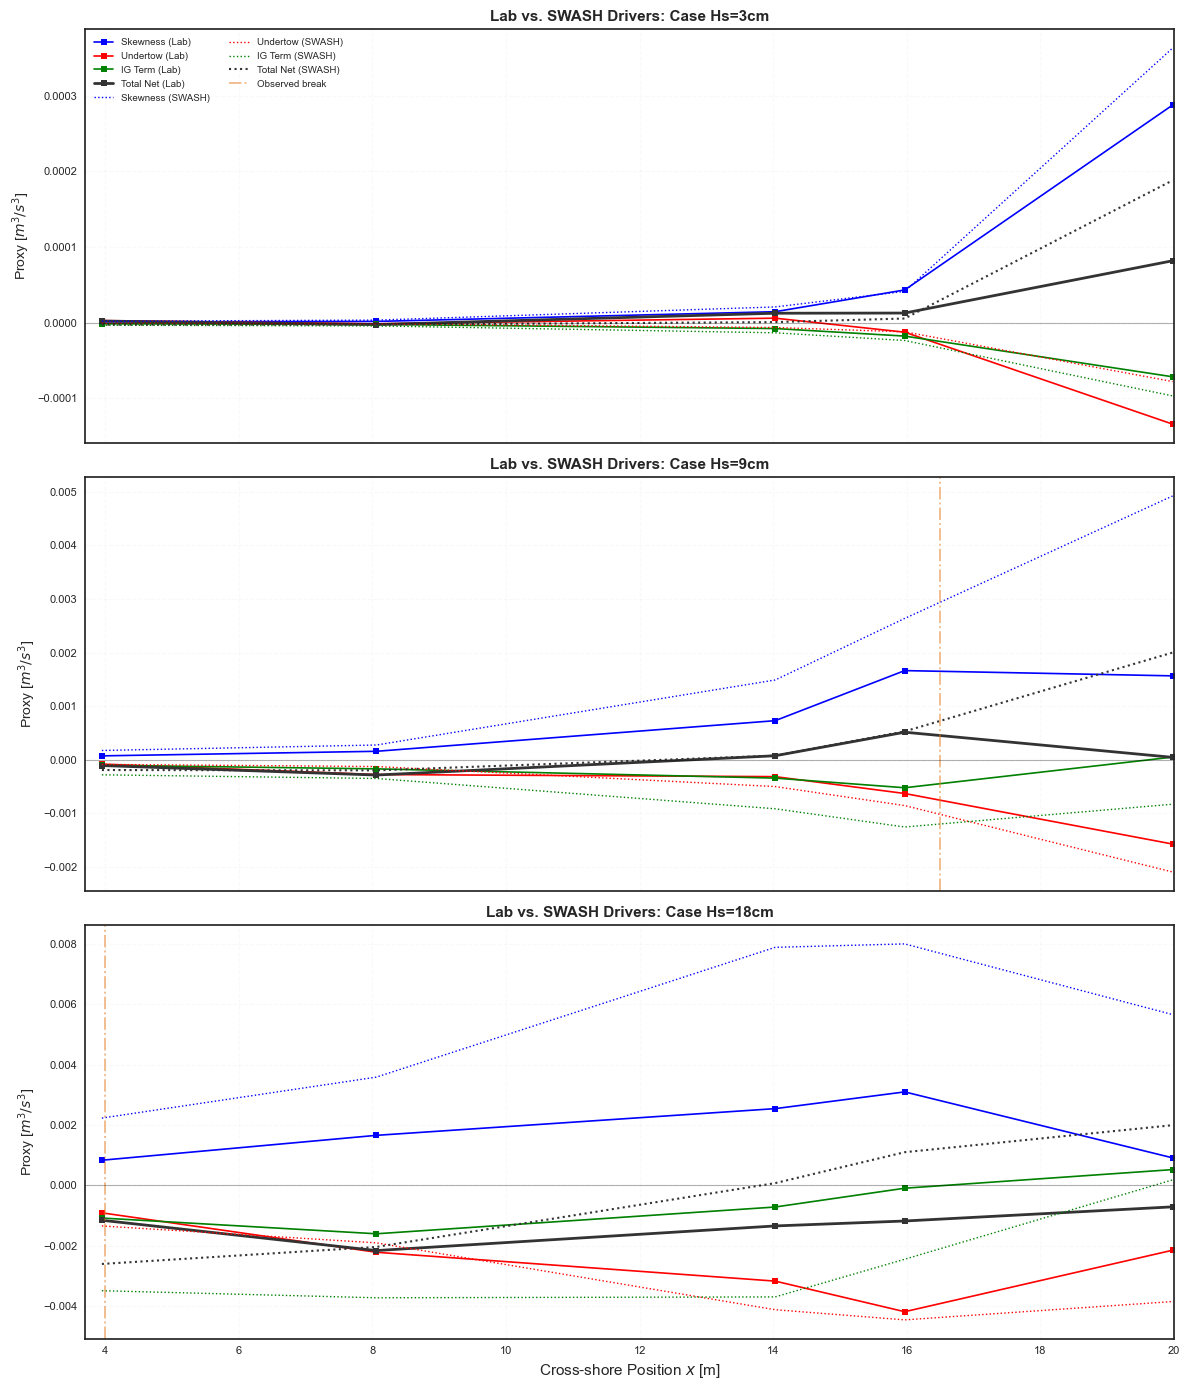

In [96]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup indices and positions
target_indices = [0, 2, 5]
pos_lab = np.array(EMF_POSITIONS) 
pos_swash = np.array(EMF_POSITIONS) 

# 2. Professional Color Palette
colors = {
    'skew': "blue",      # Midnight Blue
    'undertow': "red",  # Muted Crimson
    'ig': "green",        # Slate Purple
    'total': '#333333',     # Charcoal
    'break1': '#E67E22'     # Soft Orange
}

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

for i, idx in enumerate(target_indices):
    ax = axes[i]
    
    # --- LAB DATA (Solid/Dashed lines + Filled Markers) ---
    undertow_lab = np.array(Mean_all[idx]) + np.array(Stir_all[idx])
    m_size = 5
    
    ax.plot(pos_lab, Skew_all[idx], color=colors['skew'], marker='s', markersize=m_size, 
            linestyle='-', linewidth=1.2, label='Skewness (Lab)')
    ax.plot(pos_lab, undertow_lab, color=colors['undertow'], marker='s', markersize=m_size, 
            linestyle='-', linewidth=1.2, label='Undertow (Lab)')
    ax.plot(pos_lab, IG_all[idx], color=colors['ig'], marker='s', markersize=m_size, 
            linestyle='-', linewidth=1.2, label='IG Term (Lab)')
    ax.plot(pos_lab, Total_all[idx], color=colors['total'], marker='s', markersize=m_size, 
            linestyle='-', linewidth=2.0, label='Total Net (Lab)')

    # --- SWASH DATA (Dotted lines + Hollow Markers) ---
    undertow_sw = np.array(Mean_swash_all[idx]) + np.array(Stir_swash_all[idx])
    
    ax.plot(pos_swash, Skew_swash_all[idx], color=colors['skew'], marker='o', markersize=m_size, 
            markerfacecolor='none', linestyle=':', linewidth=1.0, label='Skewness (SWASH)')
    ax.plot(pos_swash, undertow_sw, color=colors['undertow'], marker='o', markersize=m_size, 
            markerfacecolor='none', linestyle=':', linewidth=1.0, label='Undertow (SWASH)')
    ax.plot(pos_swash, IG_swash_all[idx], color=colors['ig'], marker='o', markersize=m_size, 
            markerfacecolor='none', linestyle=':', linewidth=1.0, label='IG Term (SWASH)')
    ax.plot(pos_swash, Total_swash_all[idx], color=colors['total'], marker='o', markersize=m_size, 
            markerfacecolor='none', linestyle=':', linewidth=1.5, label='Total Net (SWASH)')

    # 4. Break Points
    off_b = BREAKPOINTS[idx][0]
    ax.axvline(x=off_b, color=colors['break1'], linestyle='-.', alpha=0.5, label='Observed break')

    # 5. Framing and Labels
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.3)
    ax.set_title(f'Lab vs. SWASH Drivers: Case {LABELS[idx]}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Proxy [$m^3/s^3$]', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.1)
    
    # 6. Legend (Placed outside or shrunk to fit)
    if i == 0:
        ax.legend(loc='upper left', fontsize=7, ncol=2, framealpha=0.9)

axes[-1].set_xlabel('Cross-shore Position $x$ [m]', fontsize=11)
plt.xlim(3.7, 20)
plt.tight_layout()
plt.show()

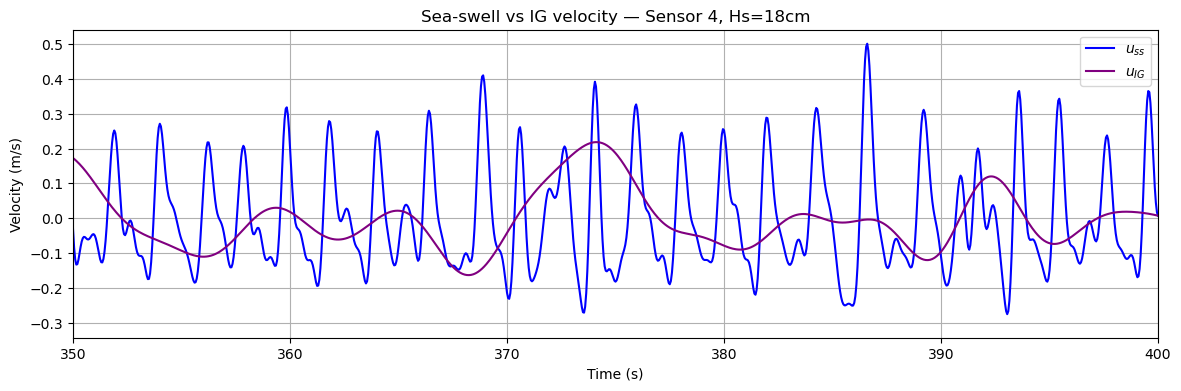

In [ ]:
u_mean = np.mean(EMF4_18)
u_dem  = EMF4_18 - u_mean
u_ss   = frequency_filter(u_dem,Fs = 20, f_low=0.25,  f_high=1.7)
u_ig   = frequency_filter(u_dem,Fs = 20, f_low=0.005, f_high=0.25)

plt.figure(figsize=(14, 4))
plt.plot(time_emf6, u_ss, color='blue',   label='$u_{ss}$')
plt.plot(time_emf6, u_ig, color='purple', label='$u_{IG}$')
plt.xlim(350, 400)
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Sea-swell vs IG velocity — Sensor 4, Hs=18cm')
plt.legend()
plt.grid()
plt.show()

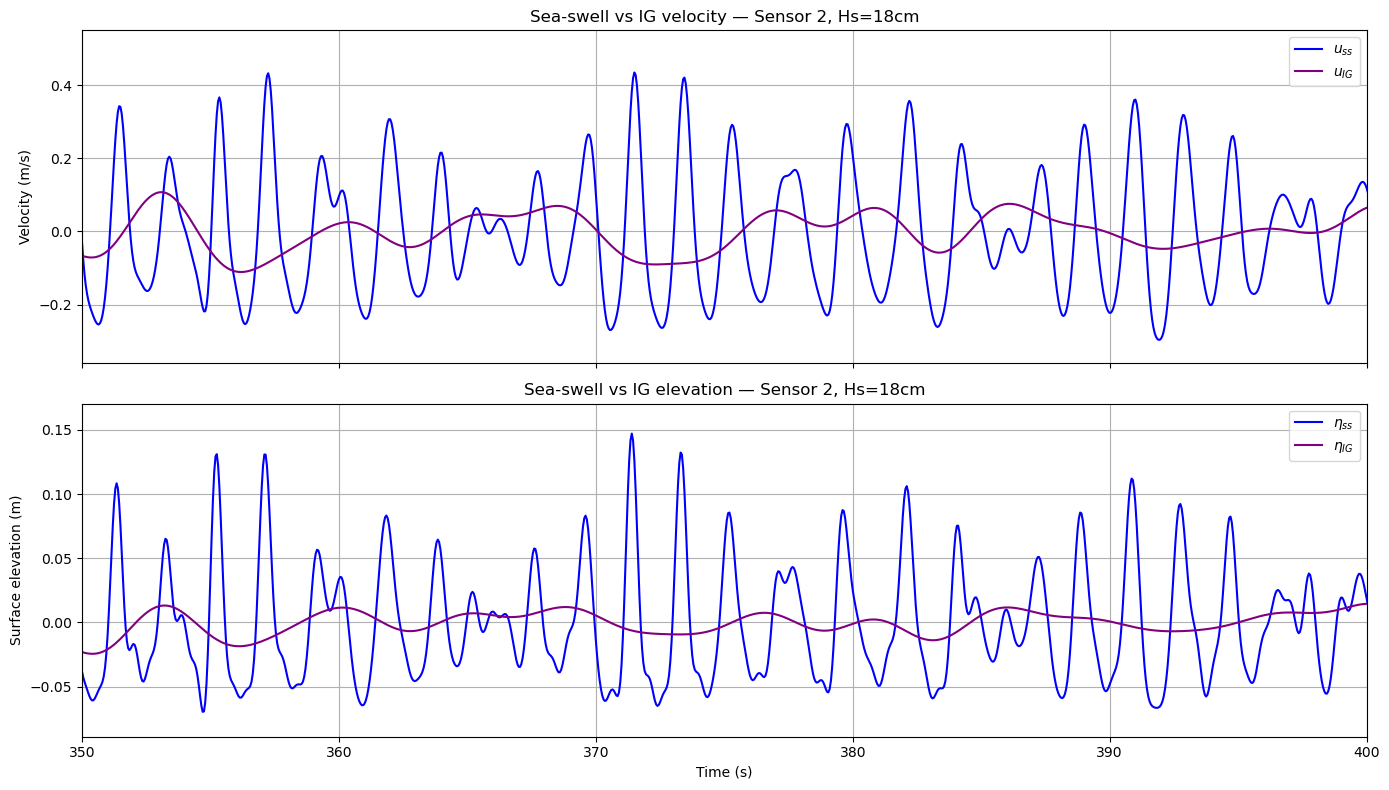

In [ ]:
u_mean  = np.mean(EMF2_18)
u_dem   = EMF2_18 - u_mean
u_ss    = frequency_filter(u_dem,Fs = 20, f_low=0.25,  f_high=1.7)
u_ig    = frequency_filter(u_dem,Fs = 20, f_low=0.005, f_high=0.25)

eta_dem = WHM2_18 - np.mean(WHM2_18)
eta_ss  = frequency_filter(eta_dem,Fs = 20, f_low=0.25,  f_high=1.7)
eta_ig  = frequency_filter(eta_dem,Fs = 20, f_low=0.005, f_high=0.25)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(time_emf6, u_ss, color='blue',   label='$u_{ss}$')
axes[0].plot(time_emf6, u_ig, color='purple', label='$u_{IG}$')
axes[0].set_ylabel('Velocity (m/s)')
axes[0].set_title('Sea-swell vs IG velocity — Sensor 2, Hs=18cm')
axes[0].legend()
axes[0].grid()

axes[1].plot(time_whm6, eta_ss, color='blue',   label='$\eta_{ss}$')
axes[1].plot(time_whm6, eta_ig, color='purple', label='$\eta_{IG}$')
axes[1].set_ylabel('Surface elevation (m)')
axes[1].set_title('Sea-swell vs IG elevation — Sensor 2, Hs=18cm')
axes[1].set_xlabel('Time (s)')
axes[1].legend()
axes[1].grid()

plt.xlim(350, 400)
plt.tight_layout()
plt.show()

Compute and plot Skewness and Asymmetry against Ursell Number:

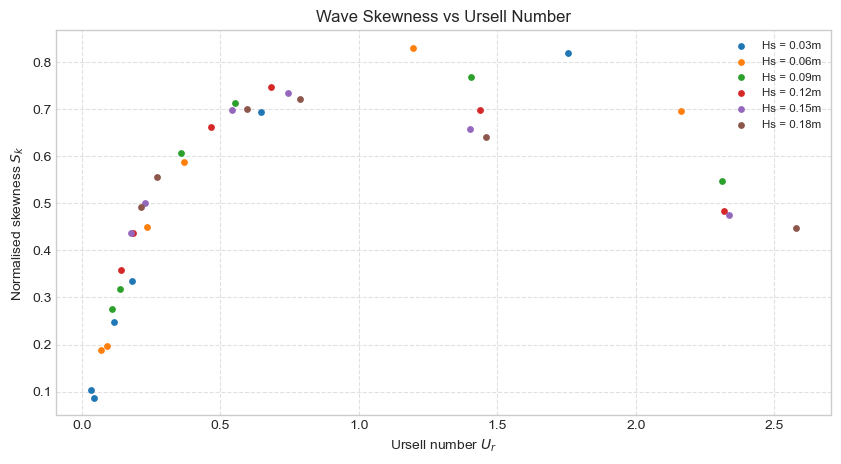

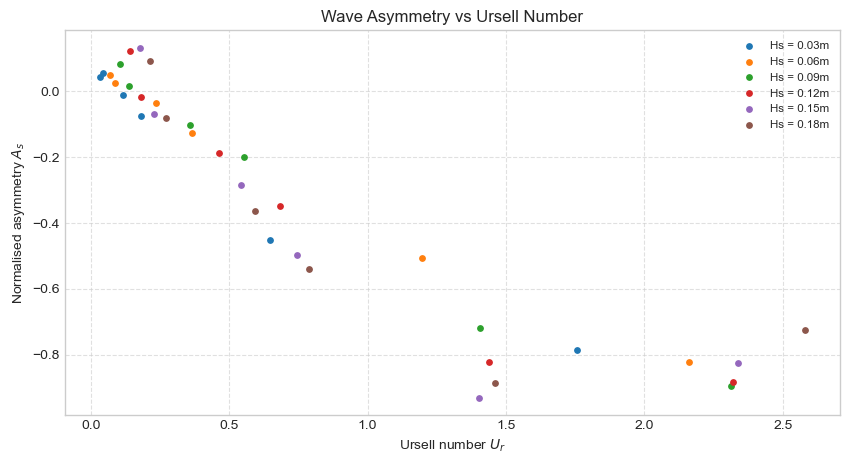

In [ ]:

Ur_all = np.zeros((6, 6))
Sk_all = np.zeros((6, 6))
As_all = np.zeros((6, 6))
labels = ['Hs = 0.03m', 'Hs = 0.06m', 'Hs = 0.09m', 'Hs = 0.12m', 'Hs = 0.15m', 'Hs = 0.18m']
# --- 3. Main Nested Loop ---
# Ensure 'zbed_sensors' is pre-calculated from your grid
water_levels = [0.510, 0.509, 0.508, 0.507, 0.506, 0.505]
T_target = 2.0
zbed_sensors = [zbed[np.argmin(np.abs(x - pos))] for pos in WHM_POSITIONS]

for i in range(6):  # Iterate through 6 experiments
    wl = water_levels[i]
    hs_case = Hm0_all[i]   # Local wave heights for this exp
    whm_case = WHM_all[i] # Surface elevation signals for this exp
    
    for j in range(6):  # Iterate through 6 sensors
        # A. Local depth including setup
        setup = np.mean(whm_case[j])
        h_local = wl - zbed_sensors[j] + setup
        
        # B. Ursell Number
        Ur, k_val = compute_ursell(hs_case[j], T_target, h_local)
        Ur_all[i, j] = Ur
        
        # C. Skewness and Asymmetry (from surface elevation)
        Sk_all[i, j] = compute_skewness(whm_case[j])
        As_all[i, j] = compute_asymmetry(whm_case[j])

labels = ['Hs = 0.03m', 'Hs = 0.06m', 'Hs = 0.09m', 'Hs = 0.12m', 'Hs = 0.15m', 'Hs = 0.18m']
# Plot 1: Skewness
plt.figure(figsize=(10, 5))
for i in range(6):
    plt.scatter(Ur_all[i], Sk_all[i], s=15, label=labels[i])
plt.xlabel('Ursell number $U_r$')
plt.ylabel('Normalised skewness $S_k$')
plt.title('Wave Skewness vs Ursell Number')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize='small')
plt.show()

# Plot 2: Asymmetry
plt.figure(figsize=(10, 5))
for i in range(6):
    plt.scatter(Ur_all[i], As_all[i], s=15, label=labels[i])
plt.xlabel('Ursell number $U_r$')
plt.ylabel('Normalised asymmetry $A_s$')
plt.title('Wave Asymmetry vs Ursell Number')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize='small')
plt.show()

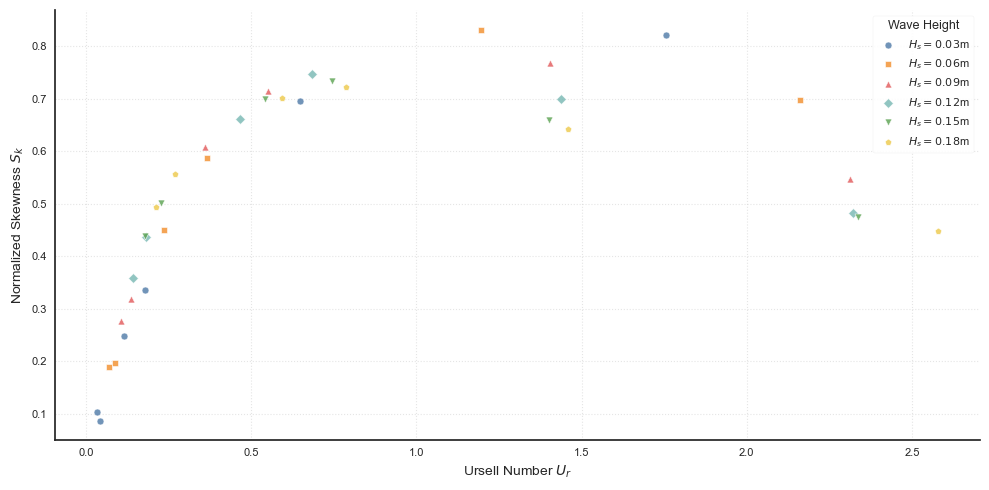

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Clean academic style
plt.style.use('seaborn-v0_8-white') 

labels = ['$H_s = 0.03$m', '$H_s = 0.06$m', '$H_s = 0.09$m', 
          '$H_s = 0.12$m', '$H_s = 0.15$m', '$H_s = 0.18$m']

# Refined, muted color palette (Tableau 10)
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948']
markers = ['o', 's', '^', 'D', 'v', 'p'] 

plt.figure(figsize=(10, 5))

for i in range(6):
    plt.scatter(Ur_all[i], Sk_all[i], 
                s=25,                 # Smaller markers for a cleaner look
                marker=markers[i], 
                color=colors[i], 
                edgecolors='white', 
                linewidths=0.5,
                alpha=0.8, 
                label=labels[i])

# Labeling
plt.xlabel('Ursell Number $U_r$', fontsize=10)
plt.ylabel('Normalized Skewness $S_k$', fontsize=10)


# Subtle grid
plt.grid(True, linestyle=':', color='0.8', alpha=0.5)

# Modern "open" plot look
plt.gca().spines[['top', 'right']].set_visible(False)

# Legend inside the plot
# 'loc=2' is Upper Left. 'frameon=True' adds the box back.
plt.legend(loc='upper right', 
           fontsize='8', 
           title='Wave Height', 
           title_fontsize='9',
           frameon=True, 
           framealpha=0.9, 
           edgecolor='0.9')

plt.tight_layout()
plt.show()